In [2]:
# import packages 
import os
import pandas as pd
import pym
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [3]:
# os.chdir(r"X:\user\crassierc\Projects\PRISMA\2_TIMER\outputlib\TIMER_3_4")
os.chdir(r'X:\user\heerdenvr\Projects\ELEVATE_LIFEMIP\2_TIMER\outputlib\TIMER_3_4\ELEVATE_LIFEMIP')

CDD_fp = r'{}\tuss\endem\residential\res_CDD.out'
HDD_fp = r'{}\tuss\endem\residential\res_HDD.out'

CDD_for_reporting_fp = r'{}\temp\CDD_for_reporting.out'

EnUse_fp = r'{}\tuss\endem\residential\res_EU.out'           # EnUseFunction_TURQ[NRCT,TURQ,6] - 5 (space heating) and 6 (space cooling)



# load mym output file as array of tuples
def load_files(fp):
    file = pym.read_mym(fp)
    return file

# load CDD data (ajusted for calib) for different base temps
CDD_old_tuple = load_files(CDD_fp.format('SSP2_CP'))
CDD_updated_18p0_tuple = load_files(CDD_fp.format('SSP2_CP_18p0_TEST'))
CDD_updated_20_tuple = load_files(CDD_fp.format('SSP2_CP_20p0_TEST'))
CDD_updated_24_tuple = load_files(CDD_fp.format('SSP2_CP_24p0_TEST'))
# CDD_updated_26_tuple = load_files(CDD_fp.format('CDD26'))

# cdd data for reporting (actual values)
# CDD_report_old_tuple = load_files(CDD_for_reporting_fp.format('SSP2'))
# CDD_report_updated_18p3_tuple = load_files(CDD_for_reporting_fp.format('CDD18p3'))
# CDD_report_updated_20_tuple = load_files(CDD_for_reporting_fp.format('CDD20'))
# CDD_report_updated_24_tuple = load_files(CDD_for_reporting_fp.format('CDD24'))
# CDD_report_updated_26_tuple = load_files(CDD_for_reporting_fp.format('CDD26'))

# CDD_report_SSP1wrong_tuple = load_files(CDD_for_reporting_fp.format('SSP1'))
# CDD_report_SSP1popweighted_tuple = load_files(CDD_for_reporting_fp.format('SSP1_NewCDDs'))

# EnUse_CDD_old_tuple = load_files(EnUse_fp.format('SSP2'))
# EnUse_CDD_updated_18p3_tuple = load_files(EnUse_fp.format('CDD18p3'))
# EnUse_CDD_updated_20_tuple = load_files(EnUse_fp.format('CDD20'))
# EnUse_CDD_updated_24_tuple = load_files(EnUse_fp.format('CDD24'))
# EnUse_CDD_updated_26_tuple = load_files(EnUse_fp.format('CDD26'))


# CDD_Morna_tuple = load_files(CDD_Morna_fp)

In [4]:
def create_dataarray(data_tuple):

    # Unpack the tuple
    data, years = data_tuple
    
    # Create coordinate arrays
    years = years
    
    if len(data_tuple[0].shape) == 4:

        regions = list(range(np.prod(data_tuple[0].shape[1])))
        turq = list(range(np.prod(data_tuple[0].shape[2])))
        dim3 = list(range(np.prod(data_tuple[0].shape[3])))
        
        # Create the DataArray
        da = xr.DataArray(
            data=data,
            dims=['year', 'region', 'turq', 'dim3'],
            coords={
                'year': years,
                'region': regions,
                'turq': turq,
                'dim3': dim3
            }
        )

    if len(data_tuple[0].shape) == 3:

        regions = list(range(np.prod(data_tuple[0].shape[1])))
        turq = list(range(np.prod(data_tuple[0].shape[2])))
        
        # Create the DataArray
        da = xr.DataArray(
            data=data,
            dims=['year', 'region', 'turq'],
            coords={
                'year': years,
                'region': regions,
                'turq': turq
            }
        )
    
    return da

In [6]:
# base temps
CDD_old = create_dataarray(CDD_old_tuple)
CDD_updated_18p3 = create_dataarray(CDD_updated_18p0_tuple)
CDD_updated_20 = create_dataarray(CDD_updated_20_tuple)
CDD_updated_24 = create_dataarray(CDD_updated_24_tuple)
# CDD_updated_26 = create_dataarray(CDD_updated_26_tuple)

# CDD_report_old = create_dataarray(CDD_report_old_tuple)
# CDD_report_updated_18p3 = create_dataarray(CDD_report_updated_18p3_tuple)
# CDD_report_updated_20 = create_dataarray(CDD_report_updated_20_tuple)
# CDD_report_updated_24 = create_dataarray(CDD_report_updated_24_tuple)
# CDD_report_updated_26 = create_dataarray(CDD_report_updated_26_tuple)

# CDD_report_SSP1wrong = create_dataarray(CDD_report_SSP1wrong_tuple)
# CDD_report_SSP1popweighted = create_dataarray(CDD_report_SSP1popweighted_tuple)

# EnUse_CDD_old = create_dataarray(EnUse_CDD_old_tuple)
# EnUse_CDD_updated_18p3 = create_dataarray(EnUse_CDD_updated_18p3_tuple)
# EnUse_CDD_updated_20 = create_dataarray(EnUse_CDD_updated_20_tuple)
# EnUse_CDD_updated_24 = create_dataarray(EnUse_CDD_updated_24_tuple)
# EnUse_CDD_updated_26 = create_dataarray(EnUse_CDD_updated_26_tuple)

# CDD_Morna = create_dataarray(CDD_Morna_tuple)

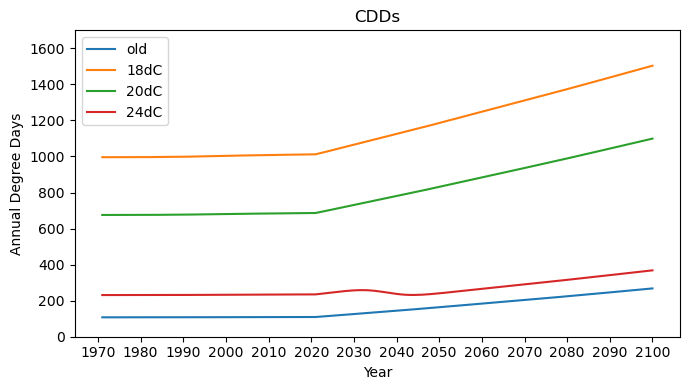

In [24]:
def plot_CDD_test(dataarray_list, region,
                  turq, month,
                     labels, ylabel, title):
    
    """
    Create a line plot comparing DataArrays over time.
    
    Parameters:
    -----------
    data... : xarray.DataArrays
    region : int or None - If None, aggregate across regions
    turq : int or None - If None, aggregate across groups
    dm3 : int/None
    labels : tuple of str, for the two datasets
    ylabel : str
    title : str
    aggregate_method : str - Method to aggregate dimensions ('mean' or 'sum')
    """

    # Function to process each dataset
    def process_data(da):
        da = da.sel(region=region)
        if turq is not None:
            da = da.sel(turq=turq)
        da = da.sel(dim3=month)
        
        return da
    
    # Create the plot
    plt.figure(figsize=(7, 4))
    index = 0

    for dataarray in dataarray_list:
        # Create copies to avoid modifying original data
        data = dataarray.copy()

        processed = process_data(data)

        # Plot both lines
        years = data.year.values
        plt.plot(years, processed.values, label=labels[index], marker='')
        
        index += 1

        # Customize the plot
        plt.xlabel('Year')
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.grid(False) #, alpha=0.3)
        plt.ylim(0,1700)
        plt.xticks(np.arange(1970, 2110, 10))
    
        # Adjust layout to prevent label cutoff
        plt.tight_layout()
    
    return plt.gcf()

# Plot for specific region and month
fig = plot_CDD_test([CDD_old, CDD_updated_18p3, CDD_updated_20, CDD_updated_24],
                     labels=('old', '18dC', '20dC', '24dC'),
                     region=1,
                     turq=0,
                     month=12,
                     ylabel='Annual Degree Days',
                     title='CDDs')

plt.show()

In [6]:
CDD_old_total = CDD_old.sum(dim='region')

CDD_SSP1popweighted_total = CDD_report_SSP1popweighted.sum(dim='region')
CDD_SSP1wrong_total = CDD_report_SSP1wrong.sum(dim='region')

CDD_updated_18p3_total = CDD_report_updated_18p3.sum(dim='region')
CDD_updated_20_total = CDD_report_updated_20.sum(dim='region')
CDD_updated_24_total = CDD_report_updated_24.sum(dim='region')
CDD_updated_26_total = CDD_updated_26.sum(dim='region')

# Plot for specific region and month - checking pop weighting across SSPs
# fig = plot_CDD_test([CDD_old_total, CDD_SSP1popweighted_total, CDD_SSP1wrong_total],
#                     turq=0,
#                      labels=('SSP2','SSP1 but wrong pop weighted','SSP1 correct pop weighted'),
#                      ylabel='Annual Degree Days',
#                      title='Global CDDs (non-adjusted)')
# plt.show()

# # Plot for specific region and month
# fig = plot_CDD_test([CDD_old_total, CDD_updated_18p3_total, CDD_updated_20_total, CDD_updated_24_total, CDD_updated_26_total],
#                     turq=0,
#                      labels=('old (Morna)','18p3 new','20 new','24 new', '26 new'),
#                      ylabel='Annual Degree Days',
#                      title='Global CDDs (non-adjusted)')

# plt.show()

In [7]:
def plot_compare_UHI(dataarray_list,
                     region, turq, dim3,
                   labels, ylabel, title):
    
    """
    Create a line plot comparing DataArrays over time.
    
    Parameters:
    -----------
    data... : xarray.DataArrays
    region : int or None - If None, aggregate across regions
    turq : int or None - If None, aggregate across groups
    dm3 : int/None
    labels : tuple of str, for the two datasets
    ylabel : str
    title : str
    aggregate_method : str - Method to aggregate dimensions ('mean' or 'sum')
    """

    # Function to process each dataset
    def process_data(da):
        da = da.sel(region=region)
        if turq is not None:
            da = da.sel(turq=turq)
        if dim3 is not None:
            da = da.sel(dim3=dim3)
        
        return da
    
    # Create the plot
    plt.figure(figsize=(7, 4))

    # to access legend label
    index = 0

    for dataarray in dataarray_list:
        # Create copies to avoid modifying original data
        data = dataarray.copy()

        # Process both datasets
        processed = process_data(data)

        # Plot both lines
        years = data.year.values
        plt.plot(years, processed.values, label=labels[index], marker='')
        index += 1
        
        # Customize the plot
        plt.xlabel('Year')
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.grid(False) #, alpha=0.3)
        plt.ylim(0,)
        plt.xticks(np.arange(1970, 2110, 10))
    
        # Adjust layout to prevent label cutoff
        plt.tight_layout()
    
    return plt.gcf()

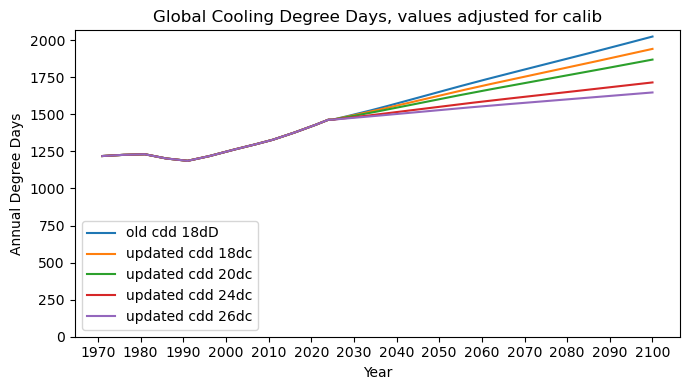

In [8]:
# Plot for specific region and month
fig = plot_compare_UHI([CDD_old, CDD_updated_18p3, CDD_updated_20, CDD_updated_24, CDD_updated_26],
                     region=2,        # 26 is total of regions
                     turq=0,
                     dim3=None,
                     labels=('old cdd 18dD', 'updated cdd 18dc', 'updated cdd 20dc', 'updated cdd 24dc', 'updated cdd 26dc'),
                     ylabel='Annual Degree Days',
                     title='Global Cooling Degree Days, values adjusted for calib')

plt.show()

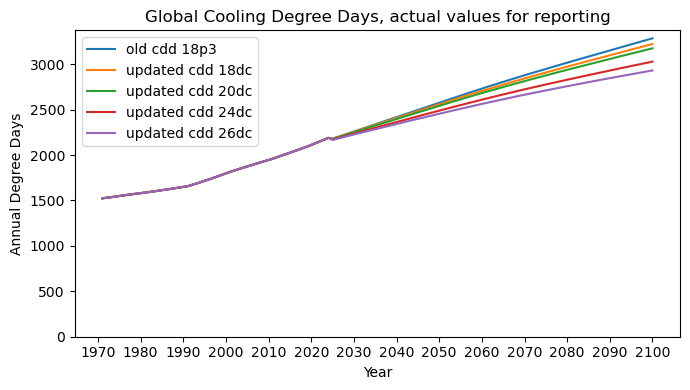

In [9]:
# Plot for specific region and month
fig = plot_compare_UHI([CDD_report_old, CDD_report_updated_18p3, CDD_report_updated_20, CDD_report_updated_24, CDD_report_updated_26],
                     region=26,        # 26 is total of regions
                     turq=0,
                     dim3=None,
                     labels=('old cdd 18p3', 'updated cdd 18dc', 'updated cdd 20dc', 'updated cdd 24dc', 'updated cdd 26dc'),
                     ylabel='Annual Degree Days',
                     title='Global Cooling Degree Days, actual values for reporting')

plt.show()

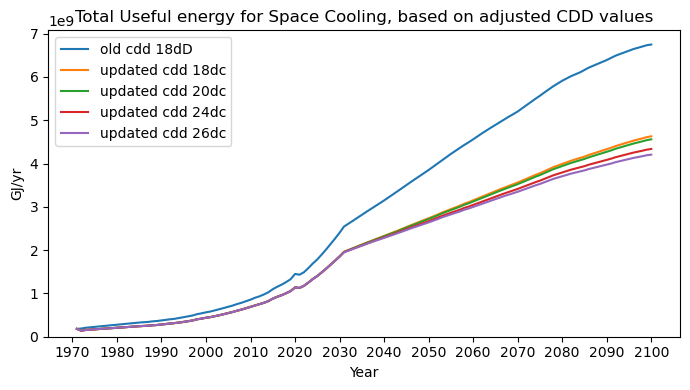

In [10]:
fig = plot_compare_UHI([EnUse_CDD_old, EnUse_CDD_updated_18p3, EnUse_CDD_updated_20, EnUse_CDD_updated_24, EnUse_CDD_updated_26],
                     region=27,     # 27 is total of all regions 
                     turq=2,
                     dim3=5,       # space cooling
                     labels=('old cdd 18dD', 'updated cdd 18dc', 'updated cdd 20dc', 'updated cdd 24dc', 'updated cdd 26dc'),
                     ylabel='GJ/yr',
                     title='Total Useful energy for Space Cooling, based on adjusted CDD values')

plt.show()